Successfully imported necessary libraries for exploritory analysis

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
from scipy.stats import pearsonr
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Import dataframes for Exploratory Data Analysis

In [112]:
life_expectancy = pd.read_csv('../Datasets/Cleaned_datasets/Life_expectancy_cleaned_1.csv').drop(columns=['Unnamed: 0'])

highest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Top_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])
lowest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Lowest_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])


In [113]:
# Descriptive statistics on all life expectancy data
descriptive_stats_life_exp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats_All_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

# Descriptive statistics for countries featuring in top and bottom 20 gdp list from years 2000 to 2015
descriptive_stats_life_exp_top_gdp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats-Top_GDP_Life_expectancy.csv').drop(columns=['Unnamed: 0'])
descriptive_stats_life_exp_bottom_gdp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats-Bottom_GDP_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

#Descriptive statistics for countries in their income classes
descriptive_stats_le_low_income = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Descriptive_Stats-Low_Income_Life_expectancy.csv').drop(columns=['Unnamed: 0'])
descriptive_stats_le_lowmiddle_income = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Descriptive_Stats-Lower_middle_income_Life_expectancy.csv').drop(columns=['Unnamed: 0'])
descriptive_stats_le_upmiddle_income = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Descriptive_Stats-Upper_middle_income_Life_expectancy.csv').drop(columns=['Unnamed: 0'])
descriptive_stats_le_high_income = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Descriptive_Stats-High_income_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

In [114]:
low_income_class = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Low_income_class.csv')
lower_middle_income_class = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Lower_middle_income_class.csv')
upper_middle_income_class = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/Upper_middle_income_class.csv')
high_income_class = pd.read_csv('../Datasets/Cleaned_datasets/EDA_Datasets/High_income_class.csv')

In [115]:
descriptive_stats_adult_mortality = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_All_Dfs/Descriptive_Stats_All_Adult_Mortality.csv')

# Organizing datasets

## Change categorical columns to category dtype

### Income Class

In [116]:
category_income_class = ['Low income', 'Lower-middle income', 'Upper-middle income', 'High income']

life_expectancy['income_class'] = pd.Categorical(life_expectancy['income_class'], categories = category_income_class, ordered = True)

### Region 

In [117]:
life_expectancy["region"] = life_expectancy["region"].astype("category")

### Sub-region

In [118]:
life_expectancy["sub_region"] = life_expectancy["sub_region"].astype("category")

# All variable correlations

## Correlation Matrices and Heatmaps

### Complete dataset

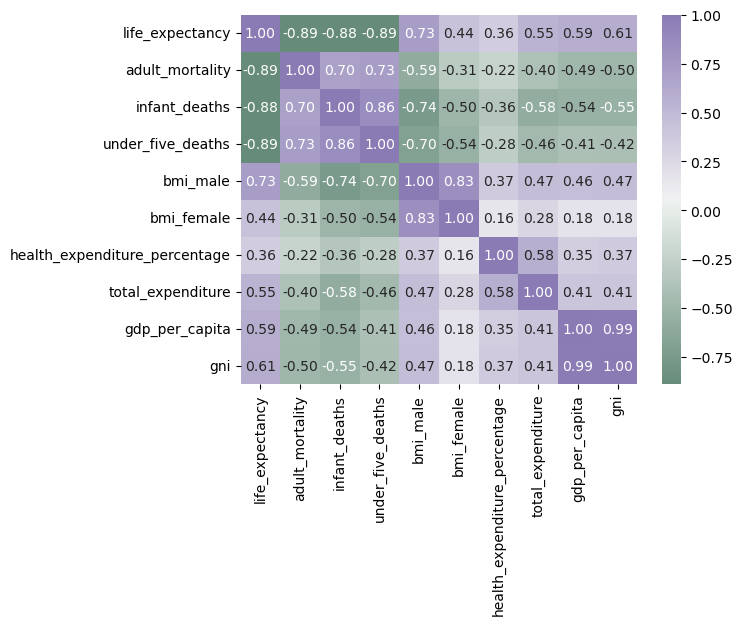

<Figure size 640x480 with 0 Axes>

In [119]:
# Dropping countries with missing values for columns adult_mortality, infant_deaths, under_five_deaths, health_expenditure_percentage, total_expenditure or unemployment_total does not affect correlation
#na_countries = ['Côte d\'Ivoire', 'Netherlands', 'The former Yugoslav republic of Macedonia', 'Turkey']
#life_expectancy_heatmap = life_expectancy[~(life_expectancy['country'].isin(na_countries))]


life_expectancy_temp = life_expectancy.copy()

# region and sub-region categories don't show significant correlation
# life_expectancy_temp['sub_region'] = LabelEncoder().fit_transform(life_expectancy_temp['sub_region'])
# life_expectancy_temp['region'] = LabelEncoder().fit_transform(life_expectancy_temp['region'])
# life_expectancy_temp['sub_region'] = life_expectancy_temp['sub_region'].astype('float64')
# life_expectancy_temp['region'] = life_expectancy_temp['region'].astype('float64')

life_expectancy_heatmap = life_expectancy_temp.select_dtypes('float64')

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(life_expectancy_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()


### Regions

#### African region

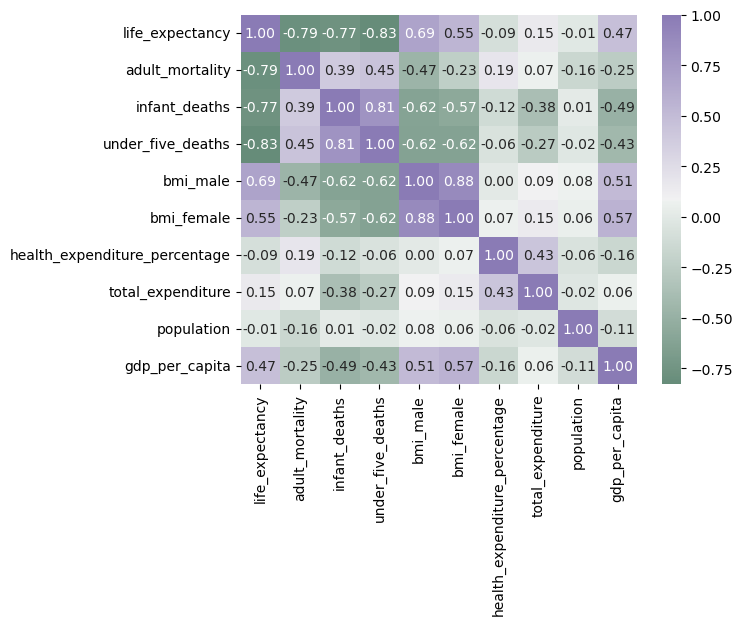

<Figure size 640x480 with 0 Axes>

In [120]:
african_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'African region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(african_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### Asian region

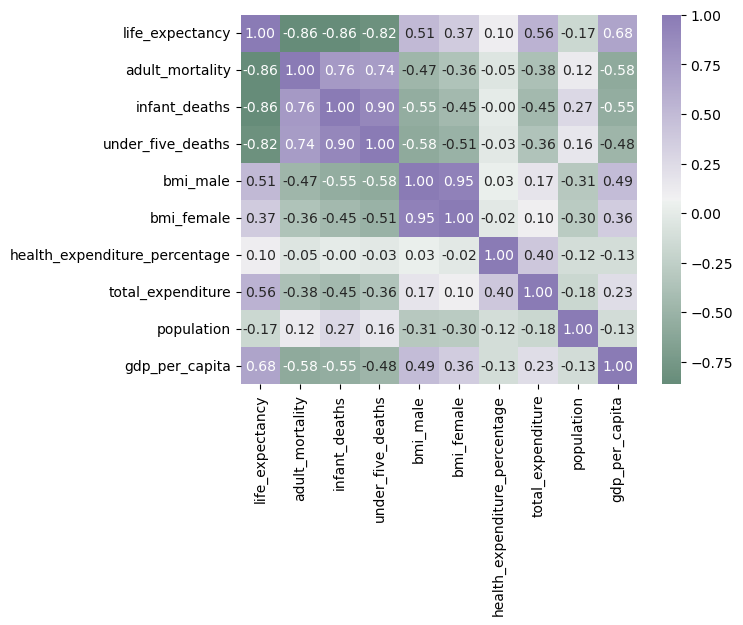

<Figure size 640x480 with 0 Axes>

In [121]:
asian_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'Asian region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(asian_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### European region

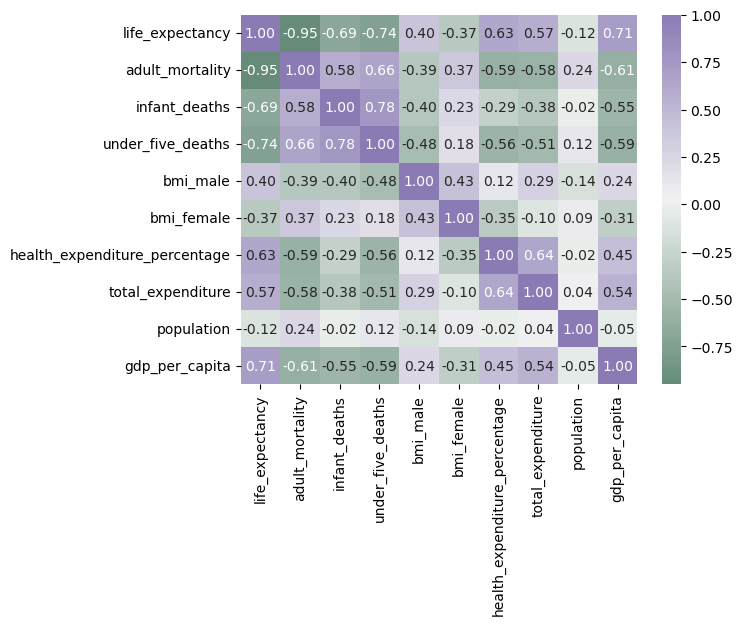

<Figure size 640x480 with 0 Axes>

In [122]:
european_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'European region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(european_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### American region

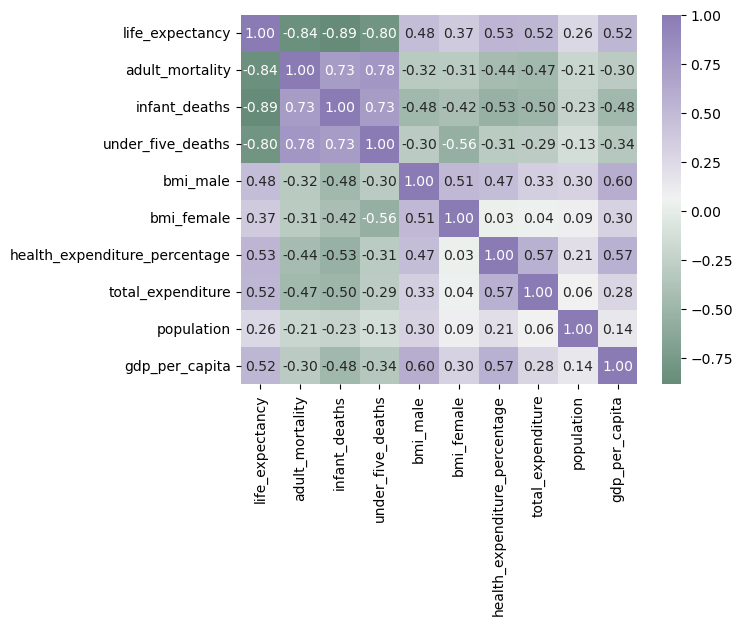

<Figure size 640x480 with 0 Axes>

In [123]:
american_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'American region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(american_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### Oceania region

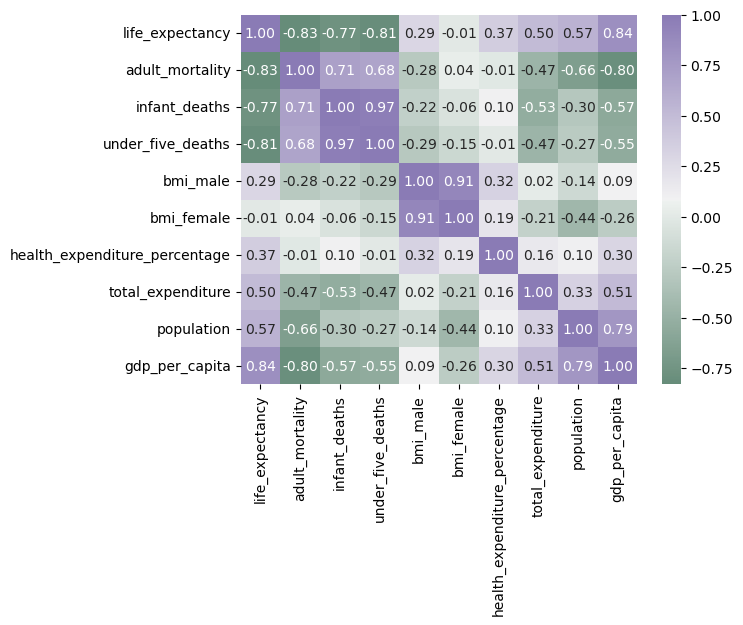

<Figure size 640x480 with 0 Axes>

In [124]:
oceania_heatmap = life_expectancy[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']][life_expectancy['region'] == 'Oceania region']

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(oceania_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

## Scatterplots

### Life Expectancy vs GDP

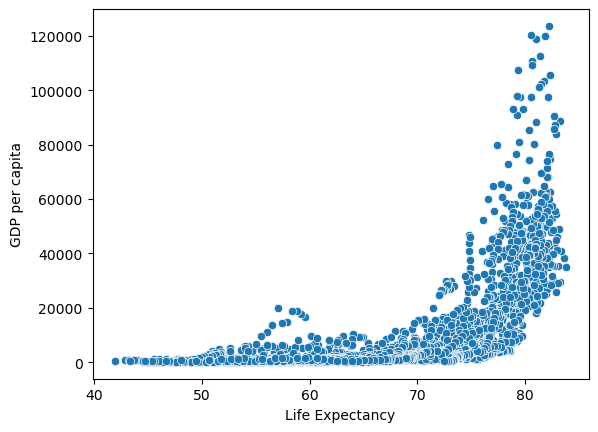

[[8.18964954e+01 9.15954776e+04]
 [9.15954776e+04 2.91856924e+08]]
0.5924563692949664


<Figure size 640x480 with 0 Axes>

In [125]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['gdp_per_capita'])
plt.xlabel("Life Expectancy")
plt.ylabel("GDP per capita")
plt.show()
plt.clf()

print(np.cov(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita']))
cor_life_exp_gdp, p = pearsonr(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita'])
print(cor_life_exp_gdp)


### Life Expectancy vs Male BMI

In [126]:
gdp_class = []
for gdp in list(life_expectancy['gdp_per_capita']):
    if gdp >= 15000:
        gdp_class.append('more than 15,000')
    else:
        gdp_class.append('less than 15,000')

life_expectancy['gdp_class'] = gdp_class

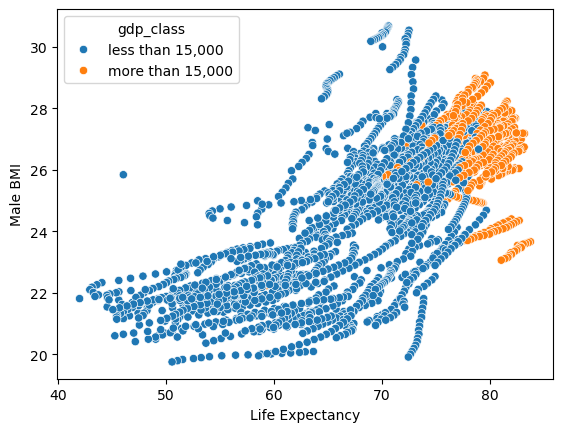

<Figure size 640x480 with 0 Axes>

In [127]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['bmi_male'], hue=life_expectancy['gdp_class'])
plt.xlabel("Life Expectancy")
plt.ylabel("Male BMI")
plt.show()
plt.clf()

### Life Expectancy vs Female BMI

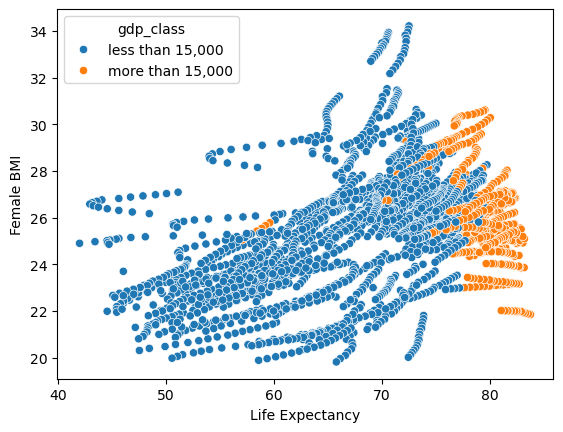

<Figure size 640x480 with 0 Axes>

In [128]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['bmi_female'], hue=life_expectancy['gdp_class'])
plt.xlabel("Life Expectancy")
plt.ylabel("Female BMI")
plt.show()
plt.clf()


### Life Expectancy vs Adult Mortality

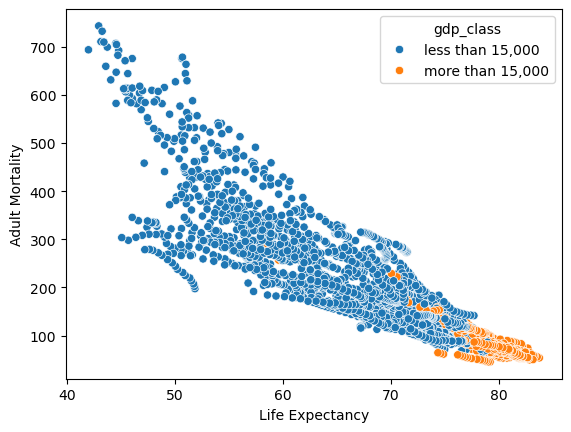

<Figure size 640x480 with 0 Axes>

In [129]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['adult_mortality'], hue=life_expectancy['gdp_class'])
plt.xlabel("Life Expectancy")
plt.ylabel("Adult Mortality")
plt.show()
plt.clf()

In [130]:
print(np.cov(life_expectancy['life_expectancy'], life_expectancy['adult_mortality']))
cor_life_exp_ad_mortality, p = pearsonr(life_expectancy['life_expectancy'], life_expectancy['adult_mortality'])
print(np.round(cor_life_exp_ad_mortality, 2))


[[   81.89649536  -935.17878942]
 [ -935.17878942 13477.95418657]]
-0.89


### Life Expectancy vs Infant Mortality

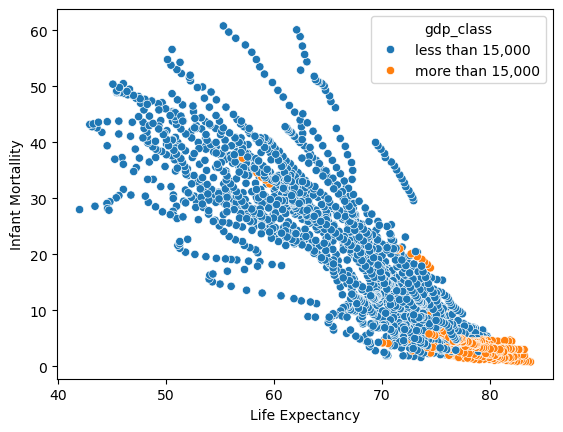

<Figure size 640x480 with 0 Axes>

In [131]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['infant_deaths'], hue=life_expectancy['gdp_class'])
plt.xlabel("Life Expectancy")
plt.ylabel("Infant Mortallity")
plt.show()
plt.clf()

### Life Expectancy vs Under 5 Mortality

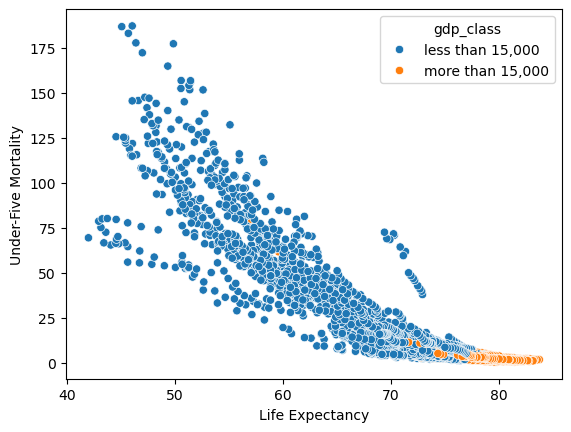

<Figure size 640x480 with 0 Axes>

In [132]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['under_five_deaths'], hue=life_expectancy['gdp_class'])
plt.xlabel("Life Expectancy")
plt.ylabel("Under-Five Mortality")
plt.show()
plt.clf()

In [133]:
high_gdp_outlier = life_expectancy[(life_expectancy['life_expectancy'] < 60) & (life_expectancy['gdp_class'] == 'more than 15,000')]
print(np.unique(high_gdp_outlier['country']))
print(descriptive_stats_life_exp)
life_expectancy = life_expectancy.drop(columns='gdp_class')


['Equatorial Guinea']
    year   mean    max max_countries  minimum min_countries  median   std  \
0   2000  66.77  81.08         Japan    44.52        Malawi   69.75  9.76   
1   2001  67.10  81.42         Japan    41.96      Zimbabwe   69.96  9.77   
2   2002  67.38  81.69         Japan    44.56      Zimbabwe   70.44  9.64   
3   2003  67.67  81.76         Japan    43.39      Zimbabwe   70.72  9.54   
4   2004  68.03  82.03         Japan    43.71       Lesotho   70.86  9.45   
5   2005  68.38  81.96         Japan    43.23       Lesotho   71.25  9.31   
6   2006  68.76  82.32         Japan    42.91       Lesotho   71.20  9.15   
7   2007  69.10  82.51         Japan    43.12       Lesotho   71.42  8.99   
8   2008  69.43  82.59         Japan    43.57       Lesotho   71.66  8.87   
9   2009  69.84  82.93         Japan    44.03       Lesotho   71.95  8.67   
10  2010  70.14  82.84         Japan    45.60       Lesotho   72.37  8.67   
11  2011  70.60  82.70   Switzerland    46.69       Le

# Explore relationship between life expectancy and GDP per capita

Display life expectancy descriptive analysis stats for lowest gdp per capita countries for the countries falling into those categories in 2015.

## Summary Statistics

### Bottom 20 GDP

In [134]:
#region life expectancy 
# print(life_expectancy.describe(include='all'))
print(descriptive_stats_life_exp_bottom_gdp)


    year   mean    max  minimum               min_country  median   std  \
0   2000  53.39  70.76    44.52                    Malawi   51.57  6.57   
1   2001  53.90  71.64    41.96                  Zimbabwe   52.39  6.72   
2   2002  54.59  71.94    44.56                  Zimbabwe   52.80  6.51   
3   2003  55.19  72.41    43.39                  Zimbabwe   53.20  6.58   
4   2004  55.94  72.47    44.50                  Zimbabwe   54.80  6.43   
5   2005  56.56  72.77    44.77                  Zimbabwe   55.30  6.38   
6   2006  57.21  73.35    45.36                  Zimbabwe   55.68  6.30   
7   2007  57.77  73.71    45.61                  Zimbabwe   56.47  6.19   
8   2008  58.15  73.55    46.72                  Zimbabwe   56.60  6.00   
9   2009  58.98  73.85    48.06                  Zimbabwe   58.10  5.94   
10  2010  59.55  73.88    49.26  Central African Republic   58.90  5.69   
11  2011  60.21  73.31    49.95  Central African Republic   59.30  5.45   
12  2012  60.58  69.55   

### Top 20 GDP

Also display life expectancy descriptive analysis stats for highest gdp per capita countries for the countries falling into those categories in 2015.

In [135]:
print(descriptive_stats_life_exp_top_gdp)

    year   mean    max  max_country  minimum  median   std    25%    75%   iqr
0   2000  77.66  81.08        Japan    44.52   77.94  2.01  76.66  79.14  2.48
1   2001  77.96  81.42        Japan    41.96   78.22  2.07  76.95  79.34  2.39
2   2002  78.10  81.69        Japan    44.56   78.26  2.06  77.14  79.46  2.32
3   2003  78.32  81.76        Japan    43.39   78.47  2.01  77.29  79.64  2.35
4   2004  78.74  82.03        Japan    44.50   79.11  2.10  77.75  80.12  2.36
5   2005  78.94  81.96        Japan    44.77   79.34  2.09  78.09  80.15  2.06
6   2006  79.18  82.32        Japan    45.36   79.54  2.13  78.36  80.70  2.34
7   2007  79.39  82.51        Japan    45.61   79.94  2.18  78.46  80.81  2.34
8   2008  79.61  82.59        Japan    46.72   80.30  2.21  78.73  81.02  2.29
9   2009  79.83  82.93        Japan    48.06   80.44  2.24  78.88  81.32  2.44
10  2010  80.06  82.84        Japan    49.26   80.66  2.22  79.29  81.52  2.23
11  2011  80.36  82.70  Switzerland    49.95   80.98

### Top and Bottom GDP Unique Countries

Calculate number of unique countries for both lowest and highest grossing countries from 2000 to 2015, to observe how many countries circulated in the highest and lowest gdp per capita area during the 16 years.

In [136]:
unique_highest_gdp_counries = []

for year in range(2000, 2016):
    le_highest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=False).reset_index(drop=True)
    le_highest_20_gdp = le_highest_20_gdp.iloc[:20]
    for country in list(le_highest_20_gdp['country']):
        if country not in unique_highest_gdp_counries:
            unique_highest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_highest_gdp_counries))} unique countries in the 20 highest grossing counries per capita range from 2000 to 2015')

unique_lowest_gdp_counries = []

for year in range(2000, 2016):
    le_lowest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=True).reset_index(drop=True)
    le_lowest_20_gdp = le_lowest_20_gdp.iloc[:20]
    for country in list(le_lowest_20_gdp['country']):
        if country not in unique_lowest_gdp_counries:
            unique_lowest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_lowest_gdp_counries))} unique countries in the 20 lowest grossing counries per capita range from 2000 to 2015')

There are 26 unique countries in the 20 highest grossing counries per capita range from 2000 to 2015
There are 30 unique countries in the 20 lowest grossing counries per capita range from 2000 to 2015


### Low Income Summary Statistics

In [137]:
print(descriptive_stats_le_low_income)

    year   mean    max         max_countries    min             min_countries  \
0   2000  52.30  70.76  Syrian Arab Republic  44.52                    Malawi   
1   2001  52.92  71.64  Syrian Arab Republic  45.39  Central African Republic   
2   2002  53.53  71.94  Syrian Arab Republic  45.41  Central African Republic   
3   2003  54.20  72.41  Syrian Arab Republic  45.76  Central African Republic   
4   2004  54.99  72.47  Syrian Arab Republic  46.04  Central African Republic   
5   2005  55.65  72.77  Syrian Arab Republic  46.43  Central African Republic   
6   2006  56.36  73.35  Syrian Arab Republic  46.85  Central African Republic   
7   2007  57.00  73.71  Syrian Arab Republic  47.43  Central African Republic   
8   2008  57.60  73.55  Syrian Arab Republic  48.02  Central African Republic   
9   2009  58.20  73.85  Syrian Arab Republic  48.65  Central African Republic   
10  2010  58.72  73.88  Syrian Arab Republic  49.26  Central African Republic   
11  2011  59.32  73.31  Syri

### Lower-middle Income Summary Statistics

In [138]:
print(descriptive_stats_le_lowmiddle_income)

    year   mean    max max_countries    min min_countries  median   std  \
0   2000  61.77  72.46      Viet Nam  44.69      Zimbabwe   62.51  7.39   
1   2001  62.05  72.65      Viet Nam  41.96      Zimbabwe   63.18  7.59   
2   2002  62.42  72.80      Viet Nam  44.56      Zimbabwe   63.57  7.46   
3   2003  62.77  72.98      Viet Nam  43.39      Zimbabwe   64.15  7.46   
4   2004  62.93  73.14      Viet Nam  43.71       Lesotho   64.66  7.31   
5   2005  63.41  73.27      Viet Nam  43.23       Lesotho   64.92  7.30   
6   2006  63.84  73.32      Viet Nam  42.91       Lesotho   65.24  7.16   
7   2007  64.19  73.44      Viet Nam  43.12       Lesotho   65.76  7.07   
8   2008  64.42  73.59        Jordan  43.57       Lesotho   66.26  6.98   
9   2009  64.88  73.80        Jordan  44.03       Lesotho   66.64  6.64   
10  2010  65.11  74.00        Jordan  45.60       Lesotho   67.04  7.01   
11  2011  65.79  74.26    Cabo Verde  46.69       Lesotho   67.40  6.26   
12  2012  66.17  74.48   

### Upper-middle Income Summary Statistics

In [139]:
print(descriptive_stats_le_upmiddle_income)

    year   mean    max max_countries    min      min_countries  median   std  \
0   2000  69.23  77.59    Costa Rica  51.01           Botswana   70.82  5.68   
1   2001  69.44  77.54    Costa Rica  50.68           Botswana   71.09  5.87   
2   2002  69.60  77.98    Costa Rica  50.63           Botswana   71.35  6.00   
3   2003  69.76  78.07    Costa Rica  50.95           Botswana   71.54  6.12   
4   2004  70.03  78.33    Costa Rica  51.25            Namibia   71.78  6.12   
5   2005  70.30  78.50    Costa Rica  51.79            Namibia   72.15  6.09   
6   2006  70.62  78.51    Costa Rica  52.66            Namibia   72.38  5.96   
7   2007  70.96  78.46    Costa Rica  53.68            Namibia   72.60  5.78   
8   2008  71.32  78.44    Costa Rica  54.65            Namibia   72.71  5.59   
9   2009  71.69  78.67    Costa Rica  55.50            Namibia   73.13  5.38   
10  2010  71.98  78.67    Costa Rica  56.02            Namibia   73.32  5.19   
11  2011  72.25  79.35    Costa Rica  56

### High Income Summary Statistics

In [140]:
print(descriptive_stats_le_high_income)

    year   mean    max max_countries    min        min_countries  median  \
0   2000  76.08  81.08         Japan  69.10  Trinidad and Tobago   76.59   
1   2001  76.43  81.42         Japan  69.65  Trinidad and Tobago   76.84   
2   2002  76.59  81.69         Japan  70.49  Trinidad and Tobago   77.07   
3   2003  76.76  81.76         Japan  69.73  Trinidad and Tobago   77.22   
4   2004  77.20  82.03         Japan  71.08  Trinidad and Tobago   77.67   
5   2005  77.36  81.96         Japan  71.25            Lithuania   78.07   
6   2006  77.60  82.32         Japan  70.87               Latvia   78.37   
7   2007  77.79  82.51         Japan  70.90            Lithuania   78.56   
8   2008  78.07  82.59         Japan  71.47  Trinidad and Tobago   78.77   
9   2009  78.37  82.93         Japan  72.58              Bahamas   78.97   
10  2010  78.65  82.84         Japan  72.72  Trinidad and Tobago   79.42   
11  2011  78.99  82.70   Switzerland  72.56              Bahamas   80.00   
12  2012  79

## Distribution diagrams

### Bottom 20 GDP

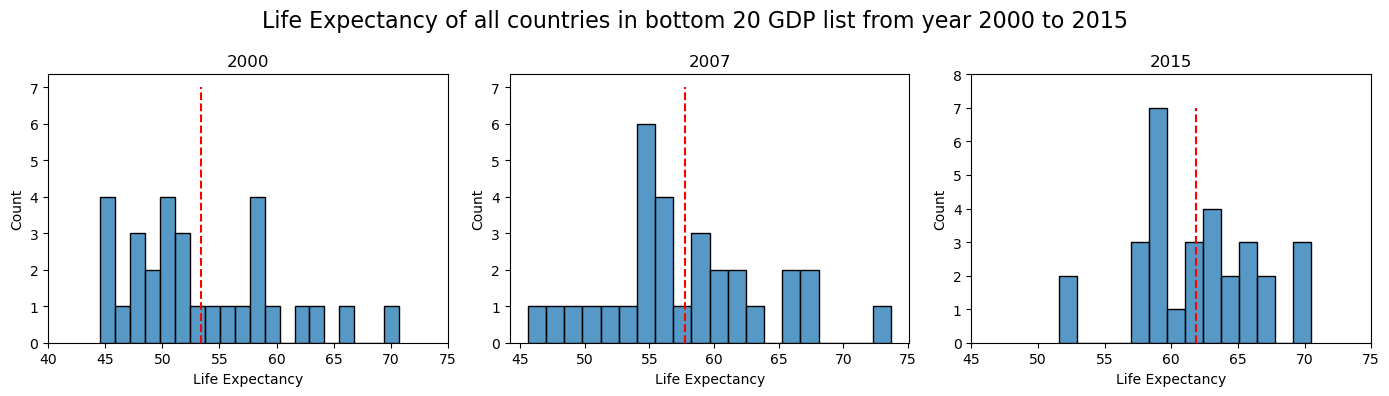

<Figure size 640x480 with 0 Axes>

In [141]:
fig, ax = plt.subplots(1, 3, figsize= (14, 4))
fig.suptitle('Life Expectancy of all countries in bottom 20 GDP list from year 2000 to 2015', fontsize = 16)

sns.histplot(data=lowest_grossing['life_expectancy'][lowest_grossing['year'] == 2000],  bins=20, ax=ax[0])
ax[0].set_title('2000')
ax[0].vlines(descriptive_stats_life_exp_bottom_gdp['mean'][descriptive_stats_life_exp_bottom_gdp['year'] == 2000], 0, 7, colors='red', linestyles='--')
ax[0].set_xlabel('Life Expectancy')
ax[0].set_xticks(range(40, 76, 5))
ax[0].set_xlim()
#ax[0].set_yticks(range(0, 9, 1))

sns.histplot(lowest_grossing['life_expectancy'][lowest_grossing['year'] == 2007], bins=20, ax=ax[1])
ax[1].vlines(descriptive_stats_life_exp_bottom_gdp['mean'][descriptive_stats_life_exp_bottom_gdp['year'] == 2007], 0, 7, colors='red', linestyles='--')
ax[1].set_title('2007')
ax[1].set_xlabel('Life Expectancy')
ax[1].set_xlim()
#ax[1].set_xticks(range(55, 86, 5))
#ax[1].set_yticks(range(0, 9, 1))

sns.histplot(lowest_grossing['life_expectancy'][lowest_grossing['year'] == 2015], bins=14, ax=ax[2])
ax[2].vlines(descriptive_stats_life_exp_bottom_gdp['mean'][descriptive_stats_life_exp_bottom_gdp['year'] == 2015], 0, 7, colors='red', linestyles='--')
ax[2].set_title('2015')
ax[2].set_xlabel('Life Expectancy')
ax[2].set_xlim()
ax[2].set_xticks(range(45, 76, 5))
ax[2].set_yticks(range(0, 9, 1))

plt.tight_layout()
plt.show()
plt.clf()

### Top 20 GDP

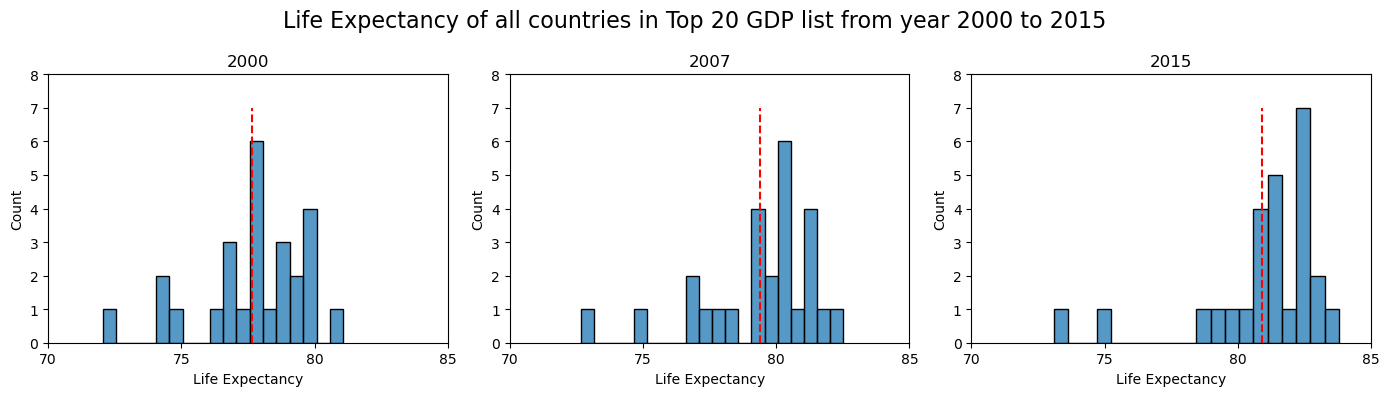

<Figure size 640x480 with 0 Axes>

In [142]:
fig, ax = plt.subplots(1, 3, figsize= (14, 4))
fig.suptitle('Life Expectancy of all countries in Top 20 GDP list from year 2000 to 2015', fontsize = 16)

sns.histplot(data=highest_grossing['life_expectancy'][highest_grossing['year'] == 2000],  bins=18, ax=ax[0])
ax[0].set_title('2000')
ax[0].vlines(descriptive_stats_life_exp_top_gdp['mean'][descriptive_stats_life_exp_top_gdp['year'] == 2000], 0, 7, colors='red', linestyles='--')
ax[0].set_xlabel('Life Expectancy')
ax[0].set_xticks(range(70, 86, 5))
ax[0].set_xlim()
ax[0].set_yticks(range(0, 9, 1))

sns.histplot(highest_grossing['life_expectancy'][highest_grossing['year'] == 2007], bins=20, ax=ax[1])
ax[1].vlines(descriptive_stats_life_exp_top_gdp['mean'][descriptive_stats_life_exp_top_gdp['year'] == 2007], 0, 7, colors='red', linestyles='--')
ax[1].set_title('2007')
ax[1].set_xlabel('Life Expectancy')
ax[1].set_xlim()
ax[1].set_xticks(range(70, 86, 5))
ax[1].set_yticks(range(0, 9, 1))

sns.histplot(highest_grossing['life_expectancy'][highest_grossing['year'] == 2015], bins=20, ax=ax[2])
ax[2].vlines(descriptive_stats_life_exp_top_gdp['mean'][descriptive_stats_life_exp_top_gdp['year'] == 2015], 0, 7, colors='red', linestyles='--')
ax[2].set_title('2015')
ax[2].set_xlabel('Life Expectancy')
ax[2].set_xlim()
ax[2].set_xticks(range(70, 86, 5))
ax[2].set_yticks(range(0, 9, 1))

plt.tight_layout()
plt.show()
plt.clf()

### Income classes

#### Low Income

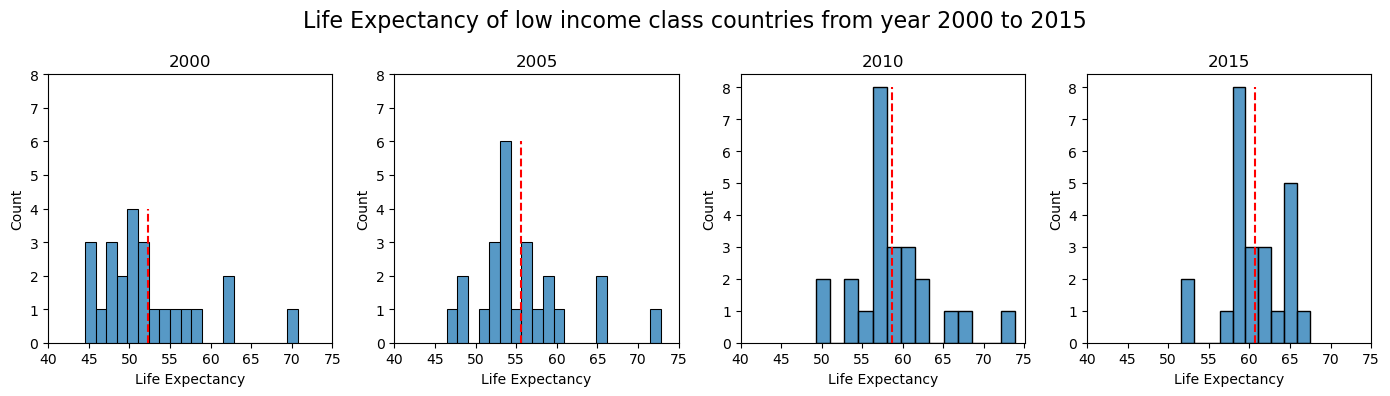

<Figure size 640x480 with 0 Axes>

In [143]:
fig, ax = plt.subplots(1, 4, figsize= (14, 4))
fig.suptitle('Life Expectancy of low income class countries from year 2000 to 2015', fontsize = 16)

sns.histplot(data=low_income_class['life_expectancy'][low_income_class['year'] == 2000],  bins=20, ax=ax[0])
ax[0].set_title('2000')
ax[0].vlines(descriptive_stats_le_low_income['mean'][descriptive_stats_le_low_income['year'] == 2000], 0, 4, colors='red', linestyles='--')
ax[0].set_xlabel('Life Expectancy')
ax[0].set_xticks(range(40, 76, 5))
ax[0].set_xlim()
ax[0].set_yticks(range(0, 9, 1))

sns.histplot(low_income_class['life_expectancy'][low_income_class['year'] == 2005], bins=20, ax=ax[1])
ax[1].vlines(descriptive_stats_le_low_income['mean'][descriptive_stats_le_low_income['year'] == 2005], 0, 6, colors='red', linestyles='--')
ax[1].set_title('2005')
ax[1].set_xlabel('Life Expectancy')
ax[1].set_xlim()
ax[1].set_xticks(range(40, 76, 5))
ax[1].set_yticks(range(0, 9, 1))

sns.histplot(low_income_class['life_expectancy'][low_income_class['year'] == 2010], bins=14, ax=ax[2])
ax[2].vlines(descriptive_stats_le_low_income['mean'][descriptive_stats_le_low_income['year'] == 2010], 0, 8, colors='red', linestyles='--')
ax[2].set_title('2010')
ax[2].set_xlabel('Life Expectancy')
ax[2].set_xlim()
ax[2].set_xticks(range(40, 76, 5))
ax[2].set_yticks(range(0, 9, 1))

sns.histplot(low_income_class['life_expectancy'][low_income_class['year'] == 2015], bins=10, ax=ax[3])
ax[3].vlines(descriptive_stats_le_low_income['mean'][descriptive_stats_le_low_income['year'] == 2015], 0, 8, colors='red', linestyles='--')
ax[3].set_title('2015')
ax[3].set_xlabel('Life Expectancy')
ax[3].set_xlim()
ax[3].set_xticks(range(40, 76, 5))
ax[3].set_yticks(range(0, 9, 1))

plt.tight_layout()
plt.show()
plt.clf()

#### Lower-middle Income

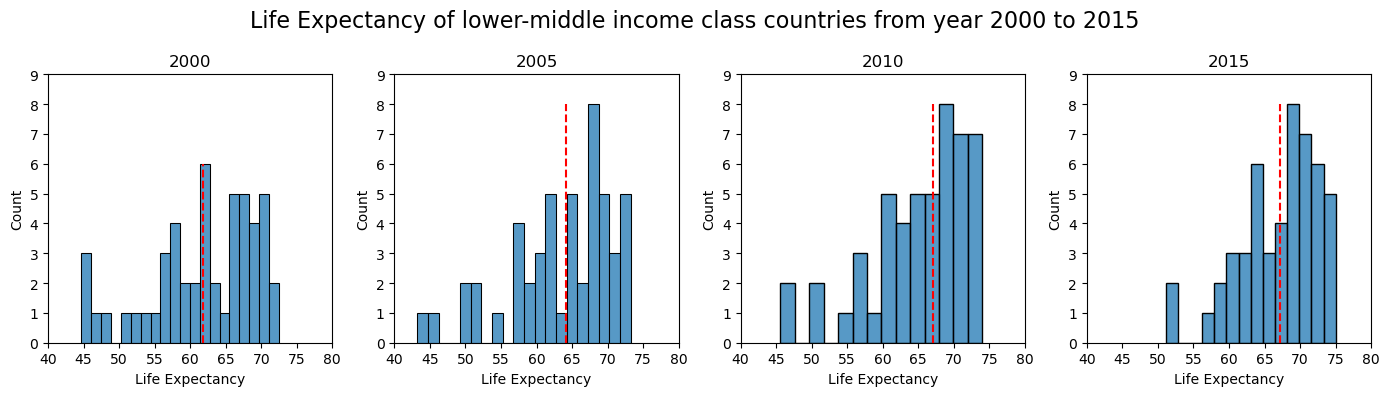

<Figure size 640x480 with 0 Axes>

In [144]:
fig, ax = plt.subplots(1, 4, figsize= (14, 4))
fig.suptitle('Life Expectancy of lower-middle income class countries from year 2000 to 2015', fontsize = 16)

sns.histplot(data=lower_middle_income_class['life_expectancy'][lower_middle_income_class['year'] == 2000],  bins=20, ax=ax[0])
ax[0].set_title('2000')
ax[0].vlines(descriptive_stats_le_lowmiddle_income['mean'][descriptive_stats_le_lowmiddle_income['year'] == 2000], 0, 6, colors='red', linestyles='--')
ax[0].set_xlabel('Life Expectancy')
ax[0].set_xticks(range(40, 81, 5))
ax[0].set_xlim()
ax[0].set_yticks(range(0, 10, 1))

sns.histplot(lower_middle_income_class['life_expectancy'][lower_middle_income_class['year'] == 2005], bins=20, ax=ax[1])
ax[1].vlines(descriptive_stats_le_lowmiddle_income['mean'][descriptive_stats_le_lowmiddle_income['year'] == 2007], 0, 8, colors='red', linestyles='--')
ax[1].set_title('2005')
ax[1].set_xlabel('Life Expectancy')
ax[1].set_xlim()
ax[1].set_xticks(range(40, 81, 5))
ax[1].set_yticks(range(0, 10, 1))

sns.histplot(lower_middle_income_class['life_expectancy'][lower_middle_income_class['year'] == 2010], bins=14, ax=ax[2])
ax[2].vlines(descriptive_stats_le_lowmiddle_income['mean'][descriptive_stats_le_lowmiddle_income['year'] == 2015], 0, 8, colors='red', linestyles='--')
ax[2].set_title('2010')
ax[2].set_xlabel('Life Expectancy')
ax[2].set_xlim()
ax[2].set_xticks(range(40, 81, 5))
ax[2].set_yticks(range(0, 10, 1))

sns.histplot(lower_middle_income_class['life_expectancy'][lower_middle_income_class['year'] == 2015], bins=14, ax=ax[3])
ax[3].vlines(descriptive_stats_le_lowmiddle_income['mean'][descriptive_stats_le_lowmiddle_income['year'] == 2015], 0, 8, colors='red', linestyles='--')
ax[3].set_title('2015')
ax[3].set_xlabel('Life Expectancy')
ax[3].set_xlim()
ax[3].set_xticks(range(40, 81, 5))
ax[3].set_yticks(range(0, 10, 1))

plt.tight_layout()
plt.show()
plt.clf()

#### Upper-middle Income

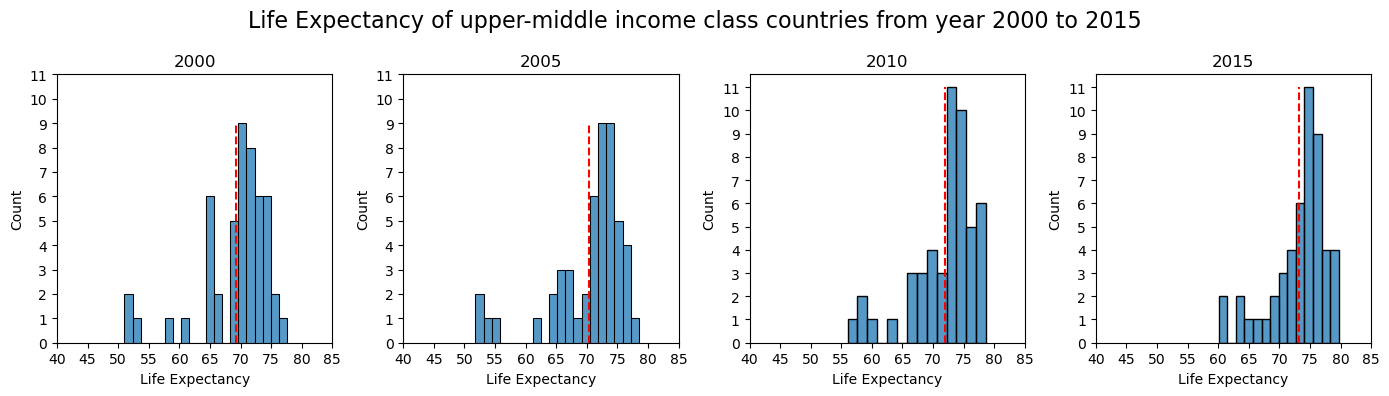

<Figure size 640x480 with 0 Axes>

In [145]:
fig, ax = plt.subplots(1, 4, figsize= (14, 4))
fig.suptitle('Life Expectancy of upper-middle income class countries from year 2000 to 2015', fontsize = 16)

sns.histplot(data=upper_middle_income_class['life_expectancy'][upper_middle_income_class['year'] == 2000],  bins=20, ax=ax[0])
ax[0].set_title('2000')
ax[0].vlines(descriptive_stats_le_upmiddle_income['mean'][descriptive_stats_le_upmiddle_income['year'] == 2000], 0, 9, colors='red', linestyles='--')
ax[0].set_xlabel('Life Expectancy')
ax[0].set_xlim()
ax[0].set_xticks(range(40, 86, 5))
ax[0].set_yticks(range(0, 12, 1))

sns.histplot(upper_middle_income_class['life_expectancy'][upper_middle_income_class['year'] == 2005], bins=20, ax=ax[1])
ax[1].vlines(descriptive_stats_le_upmiddle_income['mean'][descriptive_stats_le_upmiddle_income['year'] == 2005], 0, 9, colors='red', linestyles='--')
ax[1].set_title('2005')
ax[1].set_xlabel('Life Expectancy')
ax[1].set_xlim()
ax[1].set_xticks(range(40, 86, 5))
ax[1].set_yticks(range(0, 12, 1))

sns.histplot(upper_middle_income_class['life_expectancy'][upper_middle_income_class['year'] == 2010], bins=14, ax=ax[2])
ax[2].vlines(descriptive_stats_le_upmiddle_income['mean'][descriptive_stats_le_upmiddle_income['year'] == 2010], 0, 11, colors='red', linestyles='--')
ax[2].set_title('2010')
ax[2].set_xlabel('Life Expectancy')
ax[2].set_xlim()
ax[2].set_xticks(range(40, 86, 5))
ax[2].set_yticks(range(0, 12, 1))

sns.histplot(upper_middle_income_class['life_expectancy'][upper_middle_income_class['year'] == 2015], bins=14, ax=ax[3])
ax[3].vlines(descriptive_stats_le_upmiddle_income['mean'][descriptive_stats_le_upmiddle_income['year'] == 2015], 0, 11, colors='red', linestyles='--')
ax[3].set_title('2015')
ax[3].set_xlabel('Life Expectancy')
ax[3].set_xlim()
ax[3].set_xticks(range(40, 86, 5))
ax[3].set_yticks(range(0, 12, 1))

plt.tight_layout()
plt.show()
plt.clf()

#### High Income

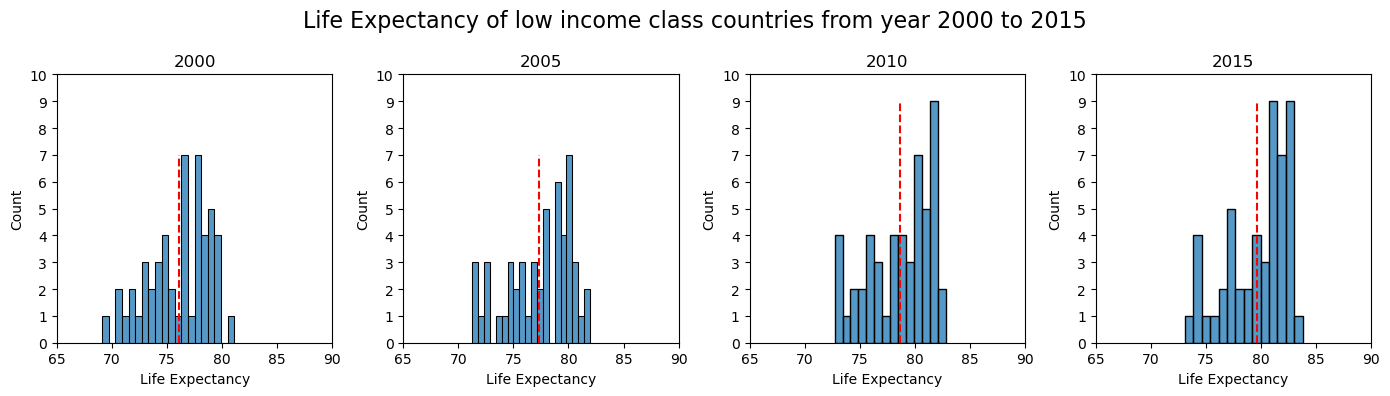

<Figure size 640x480 with 0 Axes>

In [146]:
fig, ax = plt.subplots(1, 4, figsize= (14, 4))
fig.suptitle('Life Expectancy of low income class countries from year 2000 to 2015', fontsize = 16)

sns.histplot(data=high_income_class['life_expectancy'][high_income_class['year'] == 2000],  bins=20, ax=ax[0])
ax[0].set_title('2000')
ax[0].vlines(descriptive_stats_le_high_income['mean'][descriptive_stats_le_high_income['year'] == 2000], 0, 7, colors='red', linestyles='--')
ax[0].set_xlabel('Life Expectancy')
ax[0].set_xticks(range(65, 91, 5))
ax[0].set_xlim()
ax[0].set_yticks(range(0, 11, 1))

sns.histplot(high_income_class['life_expectancy'][high_income_class['year'] == 2005], bins=20, ax=ax[1])
ax[1].vlines(descriptive_stats_le_high_income['mean'][descriptive_stats_le_high_income['year'] == 2005], 0, 7, colors='red', linestyles='--')
ax[1].set_title('2005')
ax[1].set_xlabel('Life Expectancy')
ax[1].set_xlim()
ax[1].set_xticks(range(65, 91, 5))
ax[1].set_yticks(range(0, 11, 1))

sns.histplot(high_income_class['life_expectancy'][high_income_class['year'] == 2010], bins=14, ax=ax[2])
ax[2].vlines(descriptive_stats_le_high_income['mean'][descriptive_stats_le_high_income['year'] == 2010], 0, 9, colors='red', linestyles='--')
ax[2].set_title('2010')
ax[2].set_xlabel('Life Expectancy')
ax[2].set_xlim()
ax[2].set_xticks(range(65, 91, 5))
ax[2].set_yticks(range(0, 11, 1))

sns.histplot(high_income_class['life_expectancy'][high_income_class['year'] == 2015], bins=14, ax=ax[3])
ax[3].vlines(descriptive_stats_le_high_income['mean'][descriptive_stats_le_high_income['year'] == 2015], 0, 9, colors='red', linestyles='--')
ax[3].set_title('2015')
ax[3].set_xlabel('Life Expectancy')
ax[3].set_xlim()
ax[3].set_xticks(range(65, 91, 5))
ax[3].set_yticks(range(0, 11, 1))

plt.tight_layout()
plt.show()
plt.clf()

## Heat maps

### Top GDP

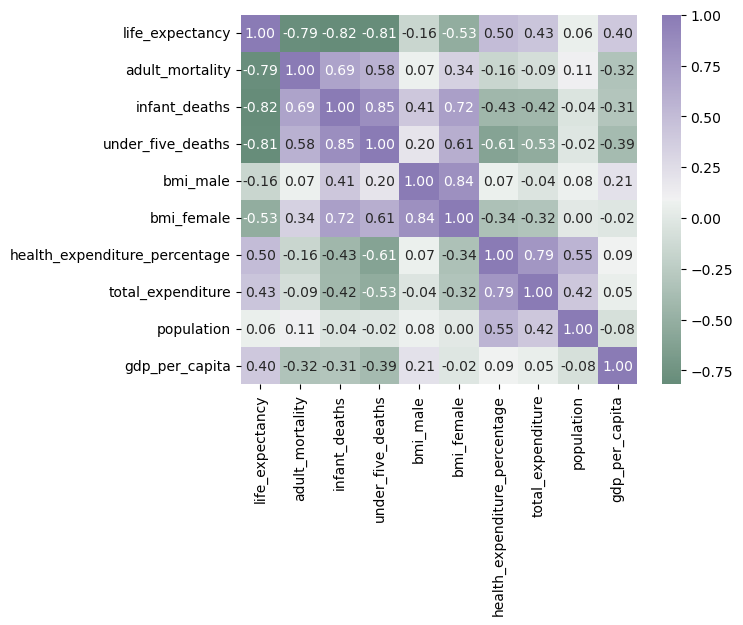

<Figure size 640x480 with 0 Axes>

In [147]:
highest_grossing_heatmap = highest_grossing[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(highest_grossing_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

### Lowest GDP

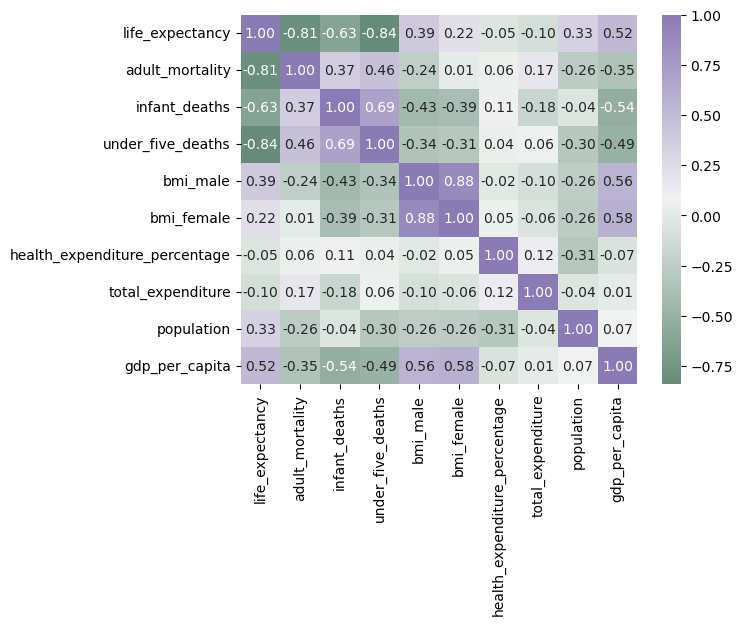

<Figure size 640x480 with 0 Axes>

In [148]:
lowest_grossing_heatmap = lowest_grossing[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(lowest_grossing_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

### Income classes

#### Low Income

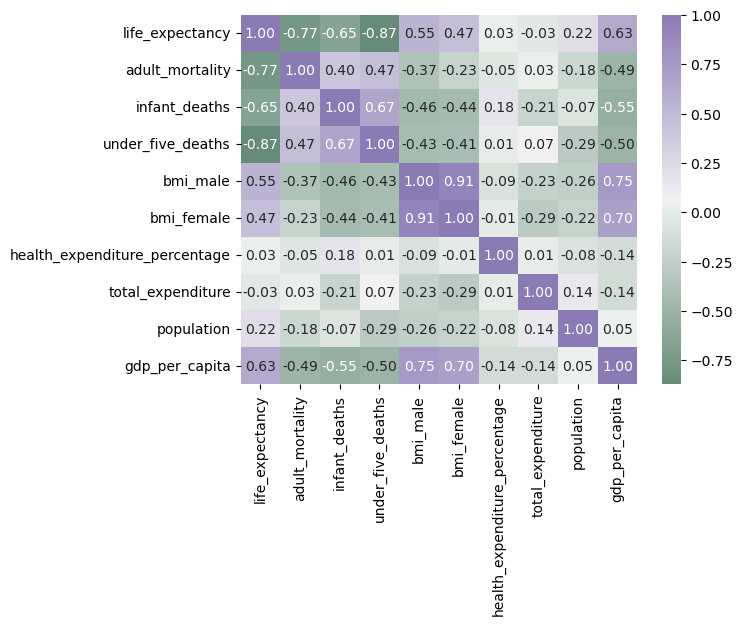

<Figure size 640x480 with 0 Axes>

In [149]:
low_income_heatmap = low_income_class[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(low_income_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### Lower-middle Income

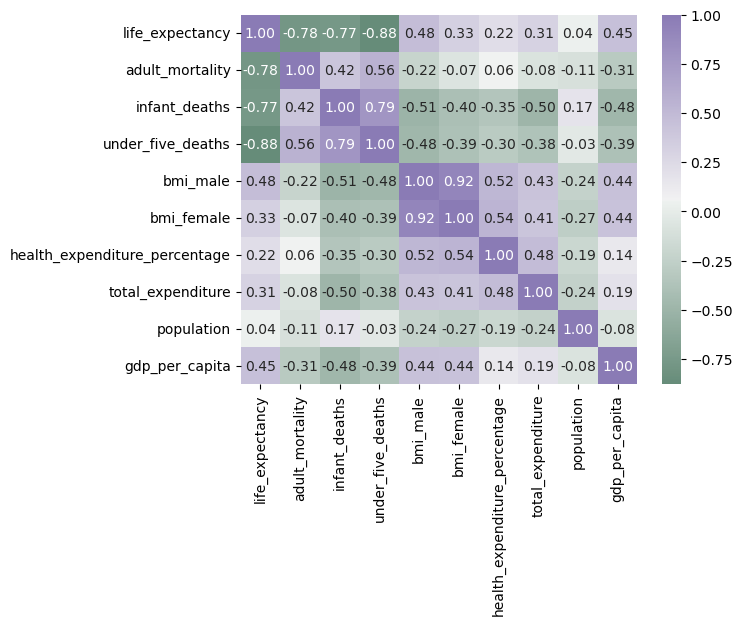

<Figure size 640x480 with 0 Axes>

In [150]:
lower_middle_income_heatmap = lower_middle_income_class[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(lower_middle_income_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### Upper-middle Income

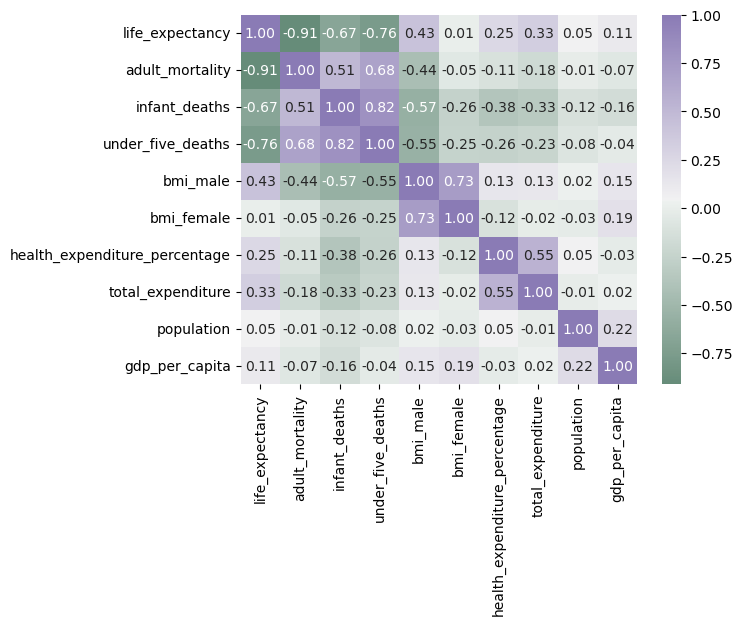

<Figure size 640x480 with 0 Axes>

In [151]:
upper_middle_income_heatmap = upper_middle_income_class[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(upper_middle_income_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

#### High Income

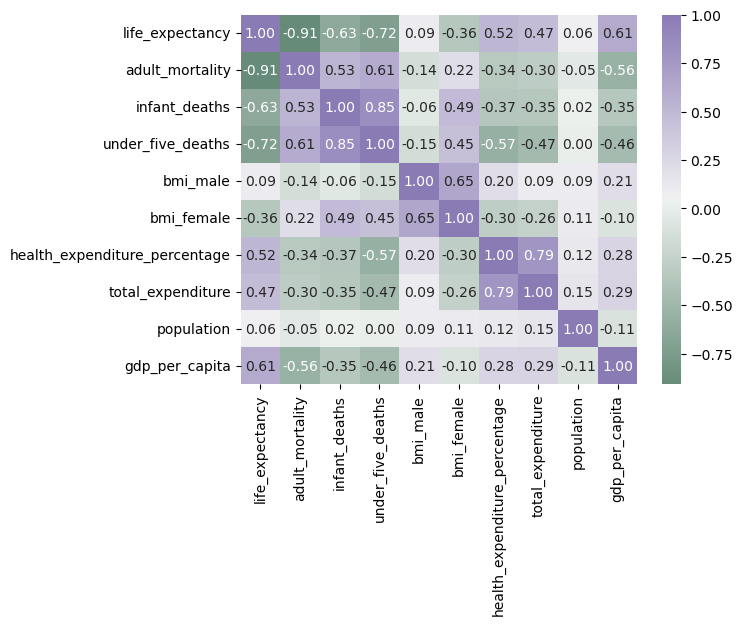

<Figure size 640x480 with 0 Axes>

In [152]:
high_income_heatmap = high_income_class[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure', 
                                   'population', 'gdp_per_capita']]

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(high_income_heatmap.corr(), annot=True, fmt=".2f", cmap=colors, robust=False)
plt.show()
plt.clf()

## Scatterplots

### All data

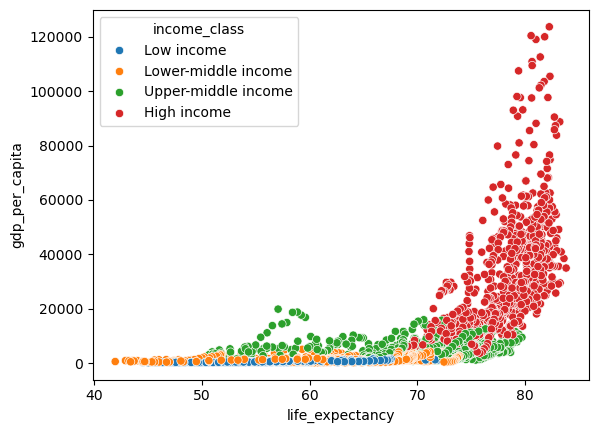

[[8.18964954e+01 9.15954776e+04]
 [9.15954776e+04 2.91856924e+08]]
0.5924563692949664


<Figure size 640x480 with 0 Axes>

In [153]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['gdp_per_capita'], hue= life_expectancy['income_class'])

plt.show()
plt.clf()

print(np.cov(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita']))
cor_life_exp_gdp, p = pearsonr(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita'])
print(cor_life_exp_gdp)


### Low Income Class

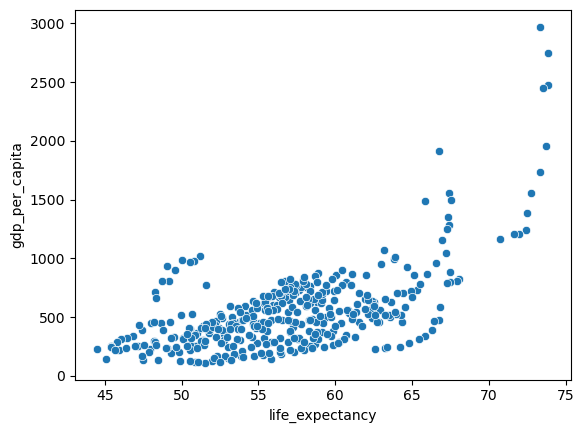

<Figure size 640x480 with 0 Axes>

In [154]:
sns.scatterplot(x=low_income_class['life_expectancy'], y=low_income_class['gdp_per_capita'])

plt.show()
plt.clf()

### Lower-middle Income Class

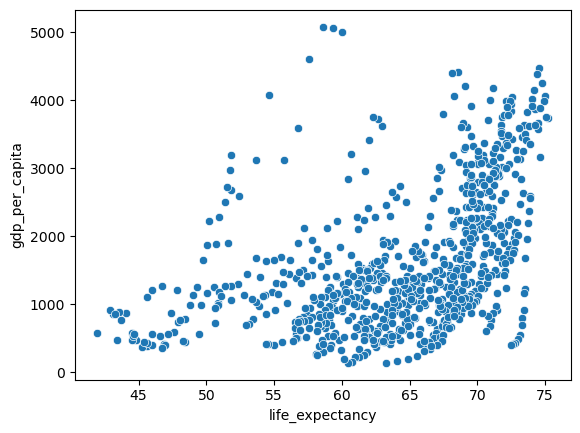

<Figure size 640x480 with 0 Axes>

In [155]:
sns.scatterplot(x=lower_middle_income_class['life_expectancy'], y=lower_middle_income_class['gdp_per_capita'])

plt.show()
plt.clf()

### Upper-middle Income Class

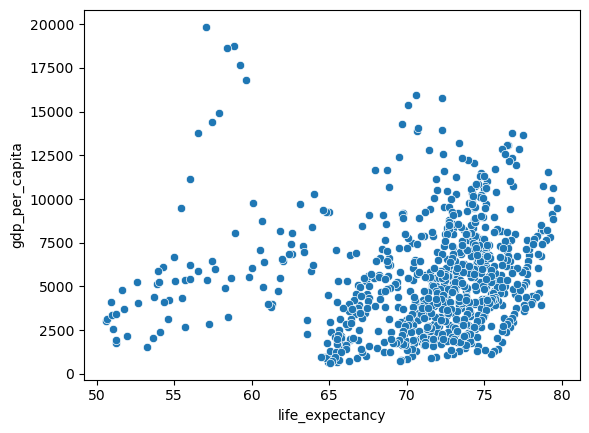

<Figure size 640x480 with 0 Axes>

In [156]:
sns.scatterplot(x=upper_middle_income_class['life_expectancy'], y=upper_middle_income_class['gdp_per_capita'])

plt.show()
plt.clf()

### High Income Class

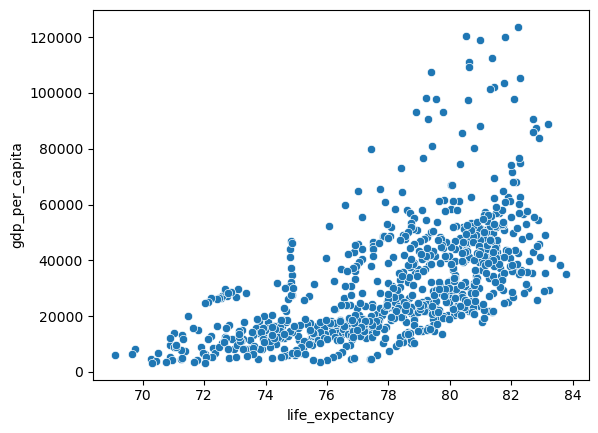

<Figure size 640x480 with 0 Axes>

In [157]:
sns.scatterplot(x=high_income_class['life_expectancy'], y=high_income_class['gdp_per_capita'])

plt.show()
plt.clf()

## Box Plots

### Top and bottom GDP (2000 to 2015)

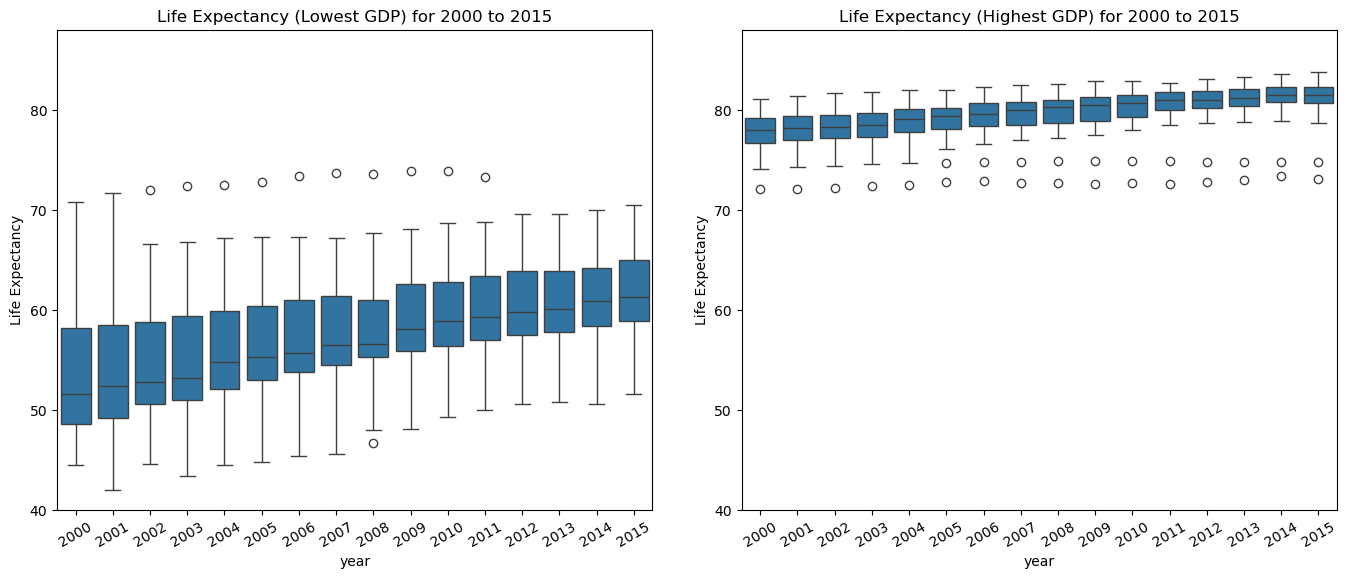

<Figure size 640x480 with 0 Axes>

In [158]:

ax2 = plt.subplot(1, 2, 1)
sns.boxplot(x = lowest_grossing['year'], y = lowest_grossing['life_expectancy'])
plt.title('Life Expectancy (Lowest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.subplots_adjust(0, 1, 2, 2, 0.15, 0)
ax4 = plt.subplot(1, 2, 2)
sns.boxplot(x = highest_grossing['year'], y = highest_grossing['life_expectancy'])
plt.title('Life Expectancy (Highest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.show()
plt.clf()

### Income classes

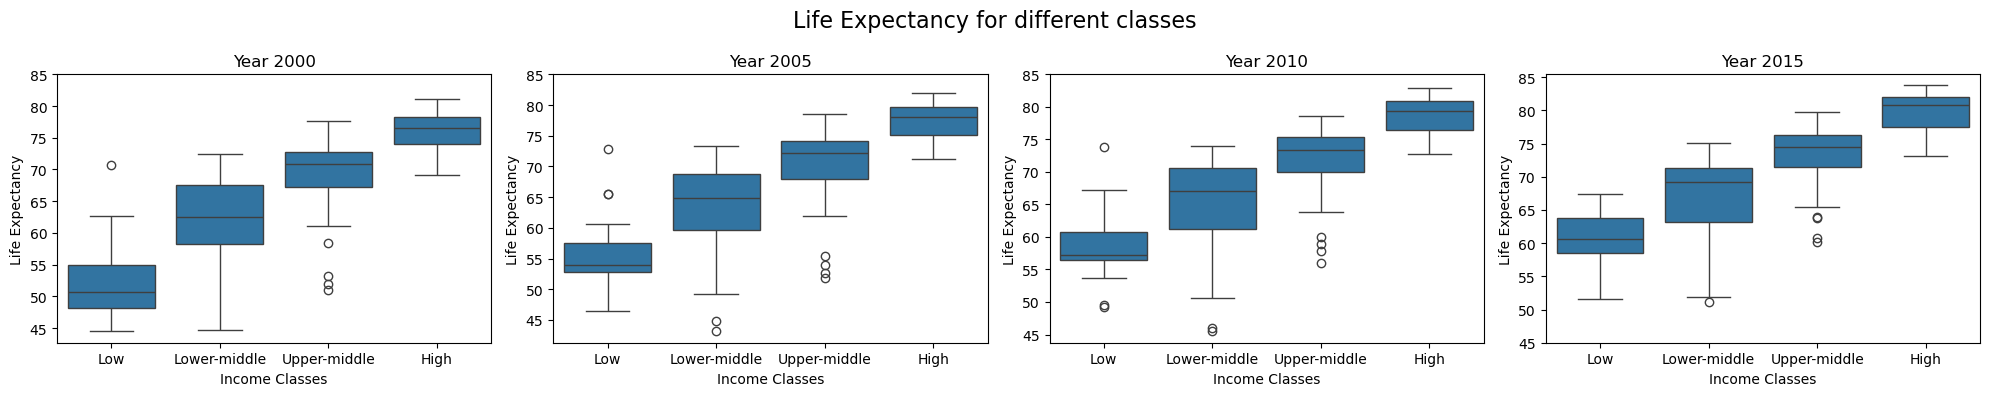

<Figure size 640x480 with 0 Axes>

In [159]:
fig, ax = plt.subplots(1, 4, figsize= (20, 4))
fig.suptitle('Life Expectancy for different classes', fontsize = 16)

sns.boxplot(data=life_expectancy, x=life_expectancy['income_class'][life_expectancy['year'] == 2000], y=life_expectancy['life_expectancy'],  ax=ax[0])
ax[0].set_title('Year 2000')
ax[0].set_ylabel('Life Expectancy')
ax[0].set_xlabel('Income Classes')
ax[0].set_xlim()
ax[0].set_xticks(range(0, 4))
ax[0].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[0].set_yticks(range(45, 86, 5))


sns.boxplot(data=life_expectancy, x=life_expectancy['income_class'][life_expectancy['year'] == 2005], y=life_expectancy['life_expectancy'],  ax=ax[1])
ax[1].set_title('Year 2005')
ax[1].set_xlabel('Income Classes')
ax[1].set_ylabel('Life Expectancy')
ax[1].set_xlim()
#ax[1].set_yticks()
ax[1].set_xticks(range(0,4))
ax[1].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[1].set_yticks(range(45, 86, 5))


sns.boxplot(data=life_expectancy, x=life_expectancy['income_class'][life_expectancy['year'] == 2010], y=life_expectancy['life_expectancy'],  ax=ax[2])
ax[2].set_title('Year 2010')
ax[2].set_ylabel('Life Expectancy')
ax[2].set_xlabel('Income Classes')
ax[2].set_xlim()
ax[2].set_xticks(range(0,4))
#ax[2].set_yticks()
#ax[2].set_xticks()
ax[2].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[2].set_yticks(range(45, 86, 5))

sns.boxplot(data=life_expectancy, x=life_expectancy['income_class'][life_expectancy['year'] == 2015], y=life_expectancy['life_expectancy'],  ax=ax[3])
ax[3].set_title('Year 2015')
ax[3].set_ylabel('Life Expectancy')
ax[3].set_xlabel('Income Classes')
ax[3].set_xlim()
ax[3].set_xticks(range(0,4))
#ax[3].set_yticks()
#ax[3].set_xticks()
ax[3].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[3].set_yticks(range(45, 86, 5))

plt.tight_layout()
plt.show()
plt.clf()

#### Low Income Class

In [160]:
valued_years = [2000, 2005, 2010, 2015]
le_low_every_5years = low_income_class[low_income_class['year'].isin(valued_years)].dropna().reset_index(drop=True)

#### Lower-middle Income Class

In [161]:
valued_years = [2000, 2005, 2010, 2015]
le_low_middle_every_5years = lower_middle_income_class[lower_middle_income_class['year'].isin(valued_years)].dropna().reset_index(drop=True)

#### Upper-middle Income Class

In [162]:
valued_years = [2000, 2005, 2010, 2015]
le_up_middle_every_5years = upper_middle_income_class[upper_middle_income_class['year'].isin(valued_years)].dropna().reset_index(drop=True)

#### High Income Class

In [163]:
valued_years = [2000, 2005, 2010, 2015]
le_high_every_5years = high_income_class[high_income_class['year'].isin(valued_years)].dropna().reset_index(drop=True)

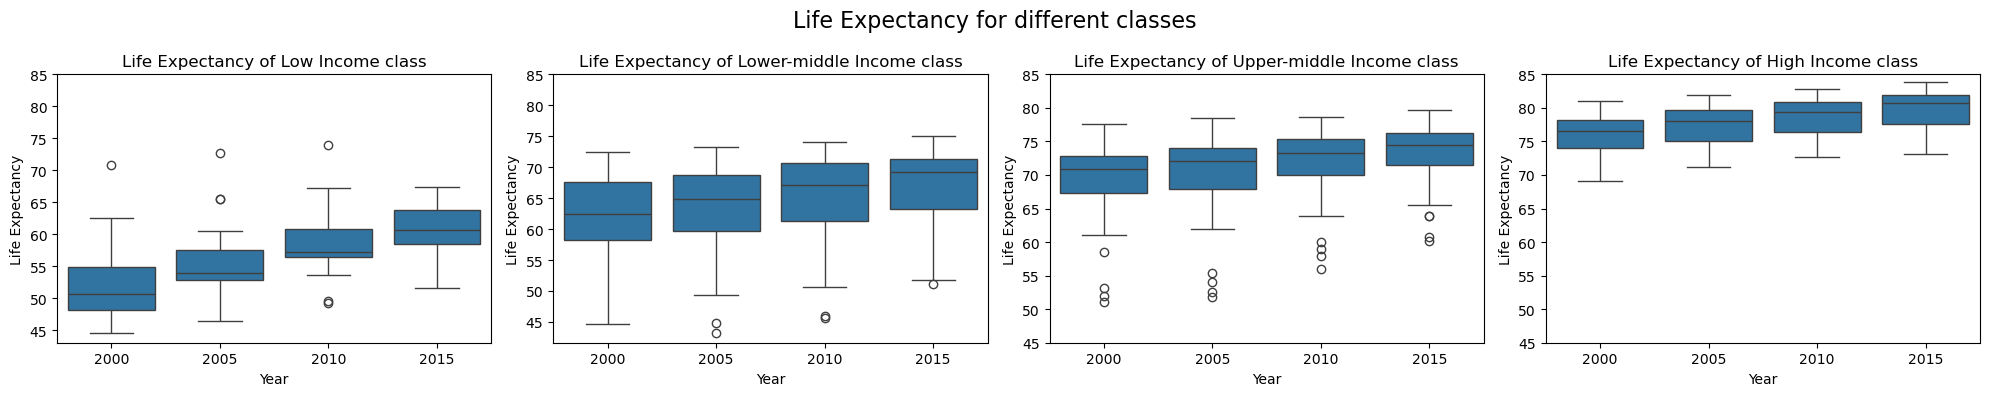

<Figure size 640x480 with 0 Axes>

In [164]:
fig, ax = plt.subplots(1, 4, figsize= (20, 4))
fig.suptitle('Life Expectancy for different classes', fontsize = 16)

sns.boxplot(data=le_low_every_5years, x=le_low_every_5years['year'], y=le_low_every_5years['life_expectancy'],  ax=ax[0])
ax[0].set_title('Life Expectancy of Low Income class')
ax[0].set_ylabel('Life Expectancy')
ax[0].set_xlabel('Year')
ax[0].set_xlim()
ax[0].set_xticks(range(0, 4))
#ax[0].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[0].set_yticks(range(45, 86, 5))


sns.boxplot(data=le_low_middle_every_5years, x=le_low_middle_every_5years['year'], y=le_low_middle_every_5years['life_expectancy'],  ax=ax[1])
ax[1].set_title('Life Expectancy of Lower-middle Income class')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Life Expectancy')
ax[1].set_xlim()
#ax[1].set_yticks()
ax[1].set_xticks(range(0,4))
#ax[1].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[1].set_yticks(range(45, 86, 5))


sns.boxplot(data=le_up_middle_every_5years, x=le_up_middle_every_5years['year'], y=le_up_middle_every_5years['life_expectancy'],  ax=ax[2])
ax[2].set_title('Life Expectancy of Upper-middle Income class')
ax[2].set_ylabel('Life Expectancy')
ax[2].set_xlabel('Year')
ax[2].set_xlim()
ax[2].set_xticks(range(0,4))
#ax[2].set_yticks()
#ax[2].set_xticks()
#ax[2].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[2].set_yticks(range(45, 86, 5))

sns.boxplot(data=le_high_every_5years, x=le_high_every_5years['year'], y=le_high_every_5years['life_expectancy'],  ax=ax[3])
ax[3].set_title('Life Expectancy of High Income class')
ax[3].set_ylabel('Life Expectancy')
ax[3].set_xlabel('Year')
ax[3].set_xlim()
ax[3].set_xticks(range(0,4))
#ax[3].set_yticks()
#ax[3].set_xticks()
#ax[3].set_xticklabels(['Low', 'Lower-middle', 'Upper-middle', 'High'])
ax[3].set_yticks(range(45, 86, 5))

plt.tight_layout()
plt.show()
plt.clf()